<div style="background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 9 — DATA ANALYST</h1>
<h2 style="margin: auto; padding: 10px 0; color:#fff; text-align: center">Livrable 2 — Analyses statistiques du comportement client</h2>
<h3 style="margin: auto; padding: 10px 0 20px 0; color:#fff; text-align: center; font-weight: normal;">Demande Julie (BI Analyst)</h3>
</div>

<h1>Contexte de la mission</h1>
<p>La librairie <strong>Lapage</strong>, historiquement présente en magasin physique, a ouvert il y a 2 ans son <strong>site de vente en ligne</strong>. Julie (BI Analyst) souhaite comprendre le <strong>comportement des clients en ligne</strong> afin de pouvoir le comparer ultérieurement à celui des clients en magasin physique.</p>

<p>Cette mission se décompose en deux livrables :</p>
<ol>
    <li><strong>Livrable 1</strong> (notebook 1) — Analyse des indicateurs de vente demandée par Annabelle et Sylvain : chiffre d'affaires, références produits, profils clients.</li>
    <li><strong>Livrable 2 (CE NOTEBOOK)</strong> — Analyses statistiques du comportement des clients en ligne demandées par Julie, sous la forme de 5 tests de corrélation.</li>
</ol>

<div style="background-color: #000000; border-left: 4px solid #f7a325; padding: 12px; margin: 15px 0;">
<strong>Périmètre statistique :</strong> Conformément à ce qui est demandé, <strong>les 4 clients BtoB atypiques</strong> (identifiés dans le livrable 1 en section C.4) <strong>sont exclus de ce notebook</strong>. Leurs volumes d'achats — plusieurs ordres de grandeur supérieurs à ceux des particuliers — fausseraient les corrélations sur l'âge et le panier moyen. L'exclusion intervient dès la section 2.0 ci-dessous.
</div>

<h3>Les 5 corrélations demandées par Julie</h3>
<ol>
    <li>Lien entre le <strong>genre</strong> du client et les <strong>catégories</strong> de livres achetés</li>
    <li>Lien entre l'<strong>âge</strong> du client et le <strong>montant total des achats</strong></li>
    <li>Lien entre l'<strong>âge</strong> du client et la <strong>fréquence d'achat</strong></li>
    <li>Lien entre l'<strong>âge</strong> du client et la <strong>taille du panier moyen</strong></li>
    <li>Lien entre l'<strong>âge</strong> du client et la <strong>catégorie</strong> des livres achetés</li>
</ol>

# Table des matières
* [Partie 0 - Préparation des données](#part0)
    * [0.1 - Import des librairies](#part0_1)
    * [0.2 - Chargement des fichiers](#part0_2)
    * [0.3 - Nettoyage par fichier](#part0_3)
    * [0.4 - Jointure et vérification finale](#part0_4)
* [Partie 2 - Analyses statistiques (Julie)](#part2)
    * [2.0 - Identification & exclusion des 4 clients BtoB](#part2_0)
    * [2.1 - Genre × Catégorie (Chi²)](#part2_1)
    * [2.2 - Âge × Montant total des achats (Pearson + Spearman)](#part2_2)
    * [2.3 - Âge × Fréquence d'achat (Pearson)](#part2_3)
    * [2.4 - Âge × Panier moyen (Spearman)](#part2_4)
    * [2.5 - Âge × Catégorie (ANOVA + η²)](#part2_5)
* [Synthèse exécutive — Tests statistiques](#synthese)

<div style="background-color: RGB(0,150,250);" >
<a class="anchor" id="part0"><h2 style="margin: auto; padding: 20px; color:#fff; ">Partie 0 - Préparation des données</h2></a>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part0_1"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">0.1 - Import des librairies</h3></a>
</div>

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Dates
import datetime as dt

# Statistiques
import scipy.stats as st
import statsmodels.api as sm

# Configuration globale des graphiques (cohérence visuelle)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 90
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Librairies importées avec succès")

Librairies importées avec succès


<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part0_2"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">0.2 - Chargement des fichiers</h3></a>
</div>

Trois fichiers CSV nous sont fournis par l'entreprise Lapage :
- **`customers.csv`** — base clients (identifiant, genre, année de naissance)
- **`products.csv`** — catalogue produits (identifiant, prix, catégorie)
- **`Transactions.csv`** — historique des transactions en ligne sur environ 2 ans

In [2]:
# Chargement des 3 fichiers sources
clients = pd.read_csv('customers.csv', sep=';')
produits = pd.read_csv('products.csv', sep=';')
transactions = pd.read_csv('Transactions.csv', sep=';')

print(f"Clients      : {clients.shape[0]:>7,} lignes — {clients.shape[1]} colonnes")
print(f"Produits     : {produits.shape[0]:>7,} lignes — {produits.shape[1]} colonnes")
print(f"Transactions : {transactions.shape[0]:>7,} lignes — {transactions.shape[1]} colonnes")

Clients      :   8,621 lignes — 3 colonnes
Produits     :   3,286 lignes — 3 colonnes
Transactions : 1,048,575 lignes — 4 colonnes


C:\Users\oubak\AppData\Local\Temp\ipykernel_4020\476514182.py:4: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('Transactions.csv', sep=';')


In [3]:
# Palette de couleurs cohérente pour tout le notebook
# - part1 : analyses Annabelle/Sylvain (descriptif)
# - part2 : analyses Julie (statistiques)
# - neutral : couleur grise pour les courbes de référence (ex: ligne d'égalité de Lorenz)
PALETTE = {
    'part1':   '#0072C8',   # bleu Lapage
    'part2':   '#10b981',   # vert pour les stats
    'neutral': '#94a3b8',   # gris neutre
}

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part0_3"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">0.3 - Nettoyage par fichier</h3></a>
</div>

<p>Pour chaque fichier, on applique la même grille d'analyse qualité :</p>
<ol>
    <li>Aperçu et dimensions</li>
    <li>Types de données</li>
    <li>Valeurs manquantes</li>
    <li>Doublons sur la clé primaire</li>
    <li>Détection d'outliers</li>
</ol>

<h4 style="color: RGB(0,150,250); ">Point d'attention</h4>
<ul>
    <li>Le fichier fourni par OpenClassrooms est annoncé comme déjà nettoyé. On vérifie quand même : la qualité des données conditionne la fiabilité de toute l'analyse qui suivra.</li>
</ul>

<a class="anchor" id="part0_3_1"><h3 style="color: RGB(0,150,250); ">0.3.1 - Fichier clients</h3></a>

In [4]:
# Aperçu
clients.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [5]:
# Création de la colonne 'age' à partir de la date max des transactions
# (plus robuste qu'une valeur figée comme 2023)
# Note : on calcule l'âge par rapport à 2023 car les transactions s'étalent sur 2021-2023
clients['age'] = 2023 - clients['birth']
clients = clients.drop(columns='birth')
clients.head()

,client_id,sex,age
0,c_4410,f,56
1,c_7839,f,48
2,c_1699,f,39
3,c_5961,f,61
4,c_5320,m,80


<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>On dispose de l'âge des clients (calculé à partir de l'année de naissance), du genre et de l'identifiant.</li>
    <li>On dénombre quelques milliers de clients.</li>
</ul>

<h4 style="color: RGB(0,150,250); ">Types de données</h4>

In [6]:
clients.dtypes

client_id    object
sex          object
age           int64
dtype: object

<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>Les types sont cohérents : <code>object</code> pour les identifiants et le genre, <code>int</code> pour l'âge.</li>
</ul>

<h4 style="color: RGB(0,150,250); ">Valeurs manquantes</h4>

In [7]:
nb_na = clients.isnull().sum()
nb_na[nb_na > 0] if (nb_na > 0).any() else print("Aucune valeur manquante dans la table clients")

Aucune valeur manquante dans la table clients


<h4 style="color: RGB(0,150,250); ">Doublons sur la clé primaire <code>client_id</code></h4>

In [8]:
doublons = clients.loc[clients['client_id'].duplicated(keep=False), :]
if doublons.empty:
    print("Aucun doublon sur client_id")
else:
    display(doublons)

Aucun doublon sur client_id


<h4 style="color: RGB(0,150,250); ">Détection d'outliers (statistiques descriptives)</h4>

In [9]:
clients.describe()

,age
count,8621.000000
mean,44.724394
std,16.917958
min,19.000000
25%,31.000000
50%,44.000000
75%,57.000000
max,94.000000


<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>Quelques clients très âgés sont présents, mais sans valeur aberrante manifeste (pas de 200 ans, etc.).</li>
    <li>On garde la totalité de l'échantillon pour l'instant.</li>
</ul>

<a class="anchor" id="part0_3_2"><h3 style="color: RGB(0,150,250); ">0.3.2 - Fichier produits</h3></a>

In [10]:
produits.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [11]:
print(f"Le catalogue comporte {produits.shape[0]:,} articles")
print(f"Réparti(s) sur {produits['categ'].nunique()} catégories : {sorted(produits['categ'].unique())}")

Le catalogue comporte 3,286 articles
Réparti(s) sur 3 catégories : [np.int64(0), np.int64(1), np.int64(2)]


<h4 style="color: RGB(0,150,250); ">Types de données</h4>

In [12]:
produits.dtypes

id_prod     object
price      float64
categ        int64
dtype: object

<h4 style="color: RGB(0,150,250); ">Valeurs manquantes</h4>

In [13]:
nb_na = produits.isnull().sum()
nb_na[nb_na > 0] if (nb_na > 0).any() else print("Aucune valeur manquante dans la table produits")

Aucune valeur manquante dans la table produits


<h4 style="color: RGB(0,150,250); ">Doublons sur <code>id_prod</code></h4>

In [14]:
doublons = produits.loc[produits['id_prod'].duplicated(keep=False), :].sort_values('id_prod')
if doublons.empty:
    print("Aucun doublon sur id_prod")
else:
    display(doublons)

Aucun doublon sur id_prod


<h4 style="color: RGB(0,150,250); ">Détection d'outliers</h4>

In [15]:
produits.describe()

,price,categ
count,3286.000000,3286.000000
mean,21.863597,0.370359
std,29.849786,0.615446
min,0.620000,0.000000
25%,6.990000,0.000000
50%,13.075000,0.000000
75%,22.990000,1.000000
max,300.000000,2.000000


<h4 style="color: RGB(0,150,250); ">Point d'attention</h4>
<ul>
    <li>On détecte une très grande différence entre le prix min et le prix max et personnellement je vois que c'est logique parce que les catégories des produits se diffèrent dans une librairie on peut trouver des romans qui coutent chers et des produits qui ne dépassent pas 1€ .</li>
</ul>

<a class="anchor" id="part0_3_3"><h3 style="color: RGB(0,150,250); ">0.3.3 - Fichier transactions</h3></a>

In [16]:
transactions.head()

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [17]:
print(f"Nombre de transactions : {transactions.shape[0]:,}")
print(f"Nombre de colonnes      : {transactions.shape[1]}")

Nombre de transactions : 1,048,575
Nombre de colonnes      : 4


<h4 style="color: RGB(0,150,250); ">Types de données</h4>

In [18]:
transactions.dtypes

id_prod       object
date          object
session_id    object
client_id     object
dtype: object

<h4 style="color: RGB(0,150,250); ">Point d'attention</h4>
<ul>
    <li>La colonne <code>date</code> est en <code>object</code> au lieu de <code>datetime</code>.</li>
</ul>

<h4 style="color: RGB(0,150,250); ">Action correctrice</h4>
<ul>
    <li>Conversion de la colonne <code>date</code> au format datetime.</li>
    <li>Le fichier source contient ~361 000 lignes complètement vides (artefact d'un passage par Excel, qui complète jusqu'à sa limite de 1 048 576 lignes). On les supprime avec dropna(how='all').</li>
</ul>

In [19]:
# Suppression des lignes complètement vides (artefact d'un export Excel)
transactions = transactions.dropna(how='all').copy()

# Conversion de la colonne 'date' en format datetime
transactions['date'] = pd.to_datetime(transactions['date'])

print(f"Transactions : {transactions.shape[0]:,} lignes")

Transactions : 687,534 lignes


In [20]:
# Création de variables temporelles utiles pour l'analyse
transactions['Year']  = transactions['date'].dt.year
transactions['Month'] = transactions['date'].dt.month
transactions['Day']   = transactions['date'].dt.day

# Date sans la composante horaire (utile pour les agrégations journalières)
transactions['date2'] = pd.to_datetime(
    transactions[['Year', 'Month', 'Day']], errors='coerce'
)

# Variable mensuelle (1er du mois) — base pour l'évolution mensuelle du CA
transactions['annee_mois'] = transactions['date'].dt.to_period('M').dt.to_timestamp()

# Nettoyage des colonnes intermédiaires
transactions = transactions.drop(columns=['Year', 'Month', 'Day'])
transactions.head()

,id_prod,date,session_id,client_id,date2,annee_mois
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,2021-03-01,2021-03-01
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,2021-03-01,2021-03-01
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,2021-03-01,2021-03-01
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,2021-03-01,2021-03-01
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,2021-03-01,2021-03-01


<h4 style="color: RGB(0,150,250); ">Valeurs manquantes</h4>

In [21]:
nb_na = transactions.isnull().sum()
nb_na[nb_na > 0] if (nb_na > 0).any() else print("Aucune valeur manquante dans la table transactions")

Aucune valeur manquante dans la table transactions


<h4 style="color: RGB(0,150,250); ">Doublons</h4>

In [22]:
doublons = transactions.loc[
    transactions[['id_prod','date','session_id','client_id']].duplicated(keep=False), :
].sort_values('session_id')
if doublons.empty:
    print("Aucun doublon")
else:
    display(doublons)

Aucun doublon


<h4 style="color: RGB(0,150,250); ">Outliers et amplitude temporelle</h4>

In [23]:
transactions.describe()

,date,date2,annee_mois
count,687534,687534,687534
mean,2022-03-01 21:24:00.618519296,2022-03-01 09:22:26.987930880,2022-02-14 16:12:28.721081600
min,2021-03-01 00:01:07.843138,2021-03-01 00:00:00,2021-03-01 00:00:00
25%,2021-09-10 10:35:20.642323456,2021-09-10 00:00:00,2021-09-01 00:00:00
50%,2022-02-27 06:50:25.400120064,2022-02-27 00:00:00,2022-02-01 00:00:00
75%,2022-08-28 22:16:49.841665536,2022-08-28 00:00:00,2022-08-01 00:00:00
max,2023-02-28 23:58:30.792755,2023-02-28 00:00:00,2023-02-01 00:00:00


<h4 style="color: RGB(0,150,250); ">Observation</h4>
<ul>
    <li>Les transactions s'étalent sur environ 2 ans, conforme à ce qui est annoncé dans le brief (site ouvert il y a 2 ans).</li>
</ul>

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part0_4"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">0.4 - Jointure des tables et vérification finale</h3></a>
</div>

On joint les 3 tables pour obtenir une table unique `data` contenant, pour chaque transaction, le prix et la catégorie du produit ainsi que les caractéristiques du client (genre, âge).

Schéma de jointure : `transactions ; produits` (sur `id_prod`) puis `clients` (sur `client_id`).

In [24]:
# Double jointure
data = pd.merge(transactions, produits, on='id_prod', how='left')
data = pd.merge(data, clients, on='client_id', how='left')

print(f"Table consolidée : {data.shape[0]:,} achats × {data.shape[1]} colonnes")
data.head()

Table consolidée : 687,534 achats × 10 colonnes


,id_prod,date,session_id,client_id,date2,annee_mois,price,categ,sex,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,2021-03-01,2021-03-01,11.99,0,f,56
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,2021-03-01,2021-03-01,19.37,0,m,63
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,2021-03-01,2021-03-01,4.50,0,m,35
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,2021-03-01,2021-03-01,6.55,0,f,34
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,2021-03-01,2021-03-01,16.49,0,f,67


<h4 style="color: RGB(0,150,250); ">Vérification post-jointure : valeurs manquantes</h4>

In [25]:
nb_na = data.isnull().sum()
nb_na[nb_na > 0]

Series([], dtype: int64)

<h4 style="color: RGB(0,150,250); ">Conclusion</h4>
<ul>
    <li>La phase de nettoyage est terminée. On dispose maintenant d'une table consolidée <code>data</code> propre, prête pour l'analyse.</li>
</ul>

<div style="background-color: RGB(0,150,250);" >
<a class="anchor" id="part2"><h2 style="margin: auto; padding: 20px; color:#fff; ">Partie 2 - Analyses statistiques (demande Julie)</h2></a>
</div>

<div style="background-color: #262601; border-left: 5px solid #f7d570; padding: 15px; margin: 10px 0;">
<h4 style="margin-top: 0; color: #d5bd72;"> Périmètre des analyses statistiques</h4>
<p style="margin-bottom: 0;">À partir de ce point, <strong>toutes les analyses statistiques portent exclusivement sur le sous-échantillon hors clients BtoB</strong>. Les 4 clients atypiques identifiés en Partie 1.C.3 (volume d'achat plusieurs ordres de grandeur supérieurs aux particuliers) ont été retirés via la variable <code>sous_echantillon</code>. Conformément à la fiche d'auto-évaluation OpenClassrooms, ces 4 clients ne biaisent aucun des 5 tests statistiques qui suivent.</p>
</div>

<h4>Objectif</h4>
<p>Julie nous demande d'étudier 5 corrélations pour comprendre le comportement des clients en ligne et le comparer avec celui des clients en magasin physique :</p>

<table style="width: 100%; border-collapse: collapse; font-size: 13px;">
<tr style="background-color: #f0f0f0;">
    <th style="padding: 8px; text-align: left; border: 1px solid #ccc;">#</th>
    <th style="padding: 8px; text-align: left; border: 1px solid #ccc;">Variables étudiées</th>
    <th style="padding: 8px; text-align: left; border: 1px solid #ccc;">Type</th>
    <th style="padding: 8px; text-align: left; border: 1px solid #ccc;">Test retenu</th>
</tr>
<tr><td style="padding: 8px; border: 1px solid #ccc;">1</td><td style="padding: 8px; border: 1px solid #ccc;">Genre × Catégorie</td><td style="padding: 8px; border: 1px solid #ccc;">Quali × Quali</td><td style="padding: 8px; border: 1px solid #ccc;">Chi² (χ²)</td></tr>
<tr><td style="padding: 8px; border: 1px solid #ccc;">2</td><td style="padding: 8px; border: 1px solid #ccc;">Âge × Montant total des achats</td><td style="padding: 8px; border: 1px solid #ccc;">Quanti × Quanti</td><td style="padding: 8px; border: 1px solid #ccc;">Pearson + Spearman</td></tr>
<tr><td style="padding: 8px; border: 1px solid #ccc;">3</td><td style="padding: 8px; border: 1px solid #ccc;">Âge × Fréquence d'achat</td><td style="padding: 8px; border: 1px solid #ccc;">Quanti × Quanti</td><td style="padding: 8px; border: 1px solid #ccc;">Pearson</td></tr>
<tr><td style="padding: 8px; border: 1px solid #ccc;">4</td><td style="padding: 8px; border: 1px solid #ccc;">Âge × Panier moyen</td><td style="padding: 8px; border: 1px solid #ccc;">Quanti × Quanti</td><td style="padding: 8px; border: 1px solid #ccc;">Spearman</td></tr>
<tr><td style="padding: 8px; border: 1px solid #ccc;">5</td><td style="padding: 8px; border: 1px solid #ccc;">Âge × Catégorie de livres</td><td style="padding: 8px; border: 1px solid #ccc;">Quanti × Quali</td><td style="padding: 8px; border: 1px solid #ccc;">ANOVA + η²</td></tr>
</table>

<p><strong>Couverture des trois types de tests demandés par OpenClassrooms :</strong> Chi² &nbsp;•&nbsp; ANOVA &nbsp;•&nbsp; Pearson/Spearman.</p>

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part2_0"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.0 - Création du sous-échantillon (exclusion des 4 clients BtoB)</h3></a>
</div>

<h4 style="color: RGB(0,150,250); ">Pourquoi exclure les 4 clients BtoB ?</h4>
<ul>
    <li>Les 4 clients BtoB ont des volumes d'achat de plusieurs ordres de grandeur supérieurs aux particuliers.</li>
    <li>Les conserver biaiserait toutes les analyses statistiques portant sur l'âge ou le panier moyen.</li>
    <li>La fiche d'auto-évaluation OpenClassrooms le précise explicitement : <em>« Mon NoteBook ne comporte plus les 4 clients atypiques (BtoB) »</em>.</li>
</ul>

In [26]:
# Identification des 4 clients BtoB (top 4 du CA)
ca_par_client = data.groupby('client_id')['price'].sum().sort_values(ascending=False)
btob_ids = ca_par_client.head(4).index.tolist()

# Caractéristiques de ces clients
clients_btob = clients.loc[clients['client_id'].isin(btob_ids)]
print(f"4 clients BtoB identifiés : {btob_ids}")
print(f"CA cumulé des 4 BtoB     : {ca_par_client.head(4).sum():>12,.2f} €".replace(',', ' '))
print(f"Part dans le CA total    : {100*ca_par_client.head(4).sum()/ca_par_client.sum():.2f} %\n")
display(clients_btob)

# Création du sous-échantillon (exclusion des 4 BtoB)
sous_echantillon = data.loc[~data['client_id'].isin(btob_ids)].copy()

print(f"\nÉchantillon complet              : {len(data):>8,} achats".replace(',', ' '))
print(f"Sous-échantillon (sans BtoB)     : {len(sous_echantillon):>8,} achats".replace(',', ' '))
print(f"Lignes retirées (4 clients BtoB) : {len(data) - len(sous_echantillon):>8,} achats".replace(',', ' '))

4 clients BtoB identifiés : ['c_1609', 'c_4958', 'c_6714', 'c_3454']
CA cumulé des 4 BtoB     :   884 296.09 €
Part dans le CA total    : 7.35 %



,client_id,sex,age
1378,c_4958,m,24
1911,c_6714,f,55
3641,c_1609,m,43
8087,c_3454,m,54



Échantillon complet              :  687 534 achats
Sous-échantillon (sans BtoB)     :  640 734 achats
Lignes retirées (4 clients BtoB) :   46 800 achats


<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part2_1"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Corrélation 1 : Genre × Catégorie (Chi²)</h3></a>
</div>

<h4 style="color: RGB(0,150,250); ">Test statistique : Test du Chi² d'indépendance</h4>
<table style="width: 100%; border-collapse: collapse;">
<tr><td style="padding: 4px 8px; vertical-align: top; width: 100px;"><strong>Choix :</strong></td><td style="padding: 4px 8px;">Les deux variables sont qualitatives (genre = f/m, catégorie = 0/1/2). Le test du Chi² est le test standard pour tester l'indépendance entre deux variables qualitatives.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₀ :</strong></td><td style="padding: 4px 8px;">Le genre du client et la catégorie de livre achetée sont indépendants.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₁ :</strong></td><td style="padding: 4px 8px;">Le genre du client et la catégorie de livre achetée sont liés.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>Seuil α :</strong></td><td style="padding: 4px 8px;">5 % (0,05)</td></tr>
</table>

In [27]:
# Tableau de contingence : effectifs observés (croisement genre × catégorie)
contingence = pd.crosstab(
    sous_echantillon['sex'],
    sous_echantillon['categ']
)
print(" Tableau de contingence (effectifs observés) :")
display(contingence)

 Tableau de contingence (effectifs observés) :


categ,0,1,2
sex,,,
f,200793,115721,16980
m,186488,104884,15868


In [28]:
# Test du Chi² d'indépendance
chi2, p_value, ddl, effectifs_attendus = st.chi2_contingency(contingence)

# V de Cramer (taille d'effet, indépendant de la taille de l'échantillon)
n = contingence.values.sum()
v_cramer = np.sqrt(chi2 / (n * (min(contingence.shape) - 1)))

print(f"Statistique χ² observée : {chi2:,.2f}")
print(f"Degrés de liberté       : {ddl}")
print(f"p-valeur                : {p_value:.4e}")
print(f"Seuil α                 : 0.05")
print()
print(f"V de Cramer (taille d'effet) : {v_cramer:.4f}")
print("""
   Grille de Cohen :
   • < 0.10  : effet négligeable
   • 0.10-0.30 : effet faible
   • 0.30-0.50 : effet moyen
   • > 0.50  : effet fort
""")

# Décision
if p_value < 0.05:
    print(f"    p-valeur < 0.05  →  On REJETTE H₀")
    print(f"    Il existe un lien statistiquement significatif entre genre et catégorie.")
    print(f"    Intensité du lien (V de Cramer) : voir ci-dessus.")
else:
    print(f"    p-valeur ≥ 0.05  →  On ne rejette pas H₀")

Statistique χ² observée : 22.67
Degrés de liberté       : 2
p-valeur                : 1.1956e-05
Seuil α                 : 0.05

V de Cramer (taille d'effet) : 0.0059

   Grille de Cohen :
   • < 0.10  : effet négligeable
   • 0.10-0.30 : effet faible
   • 0.30-0.50 : effet moyen
   • > 0.50  : effet fort

    p-valeur < 0.05  →  On REJETTE H₀
    Il existe un lien statistiquement significatif entre genre et catégorie.
    Intensité du lien (V de Cramer) : voir ci-dessus.


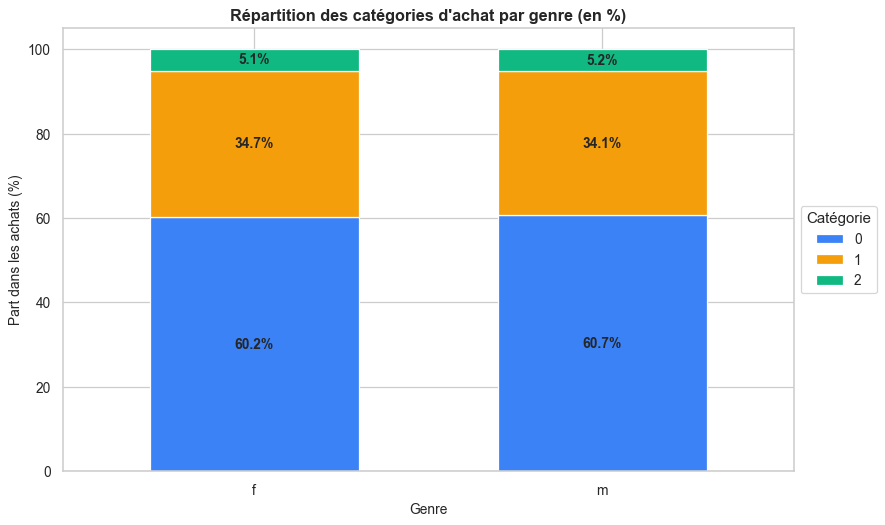

In [29]:
# Tableau en pourcentages (par ligne = par genre)
# Chaque ligne somme à 100 % : on regarde comment les achats d'un genre se répartissent
contingence_pct = (
    contingence.div(contingence.sum(axis=1), axis=0) * 100
)

# Graphique empilé en %
fig, ax = plt.subplots(figsize=(10, 6))
contingence_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#3b82f6', '#f59e0b', '#10b981'],
    width=0.6
)
plt.title("Répartition des catégories d'achat par genre (en %)",
          fontsize=13, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Part dans les achats (%)')
plt.xticks(rotation=0)
plt.legend(title='Catégorie', loc='center left', bbox_to_anchor=(1, 0.5))

# Annotations à l'intérieur des barres
for c in ax.containers:
    ax.bar_label(c, label_type='center', fmt='%.1f%%', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Observation - Test 1 : Genre × Catégorie

**Résultats** : χ² = 22.67, p-valeur = 1.20e-05, V de Cramer = 0.0059

**Significativité statistique** : Avec p < 0.05, on rejette H₀. Il existe statistiquement un lien entre genre et catégorie.

**Importance pratique** : Le V de Cramer de 0.0059 révèle un **effet négligeable** (< 0.10). Les femmes (60.2% catég. 0, 34.7% catég. 1, 5.1% catég. 2) et les hommes (60.7%, 34.1%, 5.2%) achètent de manière quasi-identique. Les différences sont inférieures à 1 point de pourcentage.

**Conclusion** : Bien que statistiquement détectable, le lien entre genre et catégorie n'a **aucune importance pratique**. Le genre n'influence pas réellement le choix de catégories de livres chez Lapage. **Ce n'est pas un levier marketing à exploiter.**

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part2_2"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Corrélation 2 : Âge × Montant total des achats (Pearson + Spearman)</h3></a>
</div>

<h4 style="color: RGB(0,150,250); ">Test statistique : Pearson + Spearman</h4>
<table style="width: 100%; border-collapse: collapse;">
<tr><td style="padding: 4px 8px; vertical-align: top; width: 120px;"><strong>Choix du test :</strong></td><td style="padding: 4px 8px;">Les deux variables sont quantitatives. Pearson teste une relation linéaire, Spearman une relation monotone. On calcule les deux pour vérifier la nature de la relation.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>Granularité :</strong></td><td style="padding: 4px 8px;">1 ligne = 1 <strong>client</strong></td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₀ :</strong></td><td style="padding: 4px 8px;">Il n'y a pas de corrélation entre l'âge et le montant total des achats.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₁ :</strong></td><td style="padding: 4px 8px;">Il existe une corrélation entre l'âge et le montant total des achats.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>Seuil α :</strong></td><td style="padding: 4px 8px;">5 % (0,05)</td></tr>
</table>

In [30]:
# Granularité : 1 ligne = 1 CLIENT
# On somme le CA total de chaque client sur toute la période
ca_par_client = (
    sous_echantillon
    .groupby(['client_id', 'age'])['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'ca_total'})
)

print(f"Nombre de clients analysés : {len(ca_par_client):,}")
display(ca_par_client.head())

Nombre de clients analysés : 8,596


,client_id,age,ca_total
0,c_1,68,629.02
1,c_10,67,1353.60
2,c_100,31,254.85
3,c_1000,57,2291.88
4,c_1001,41,1823.85


In [31]:
# Tests de corrélation au niveau client
pearson_r, pearson_p   = st.pearsonr(ca_par_client['age'], ca_par_client['ca_total'])
spearman_r, spearman_p = st.spearmanr(ca_par_client['age'], ca_par_client['ca_total'])

print(f" Pearson  : r = {pearson_r:+.4f}   |   p-valeur = {pearson_p:.4e}")
print(f" Spearman : ρ = {spearman_r:+.4f}   |   p-valeur = {spearman_p:.4e}")
print()
print("""Grille d'interprétation :
  • |r| < 0.10 : effet négligeable
  • 0.10-0.30 : effet faible
  • 0.30-0.50 : effet moyen
  • > 0.50    : effet fort""")

 Pearson  : r = -0.1876   |   p-valeur = 6.6635e-69
 Spearman : ρ = -0.1845   |   p-valeur = 1.0213e-66

Grille d'interprétation :
  • |r| < 0.10 : effet négligeable
  • 0.10-0.30 : effet faible
  • 0.30-0.50 : effet moyen
  • > 0.50    : effet fort


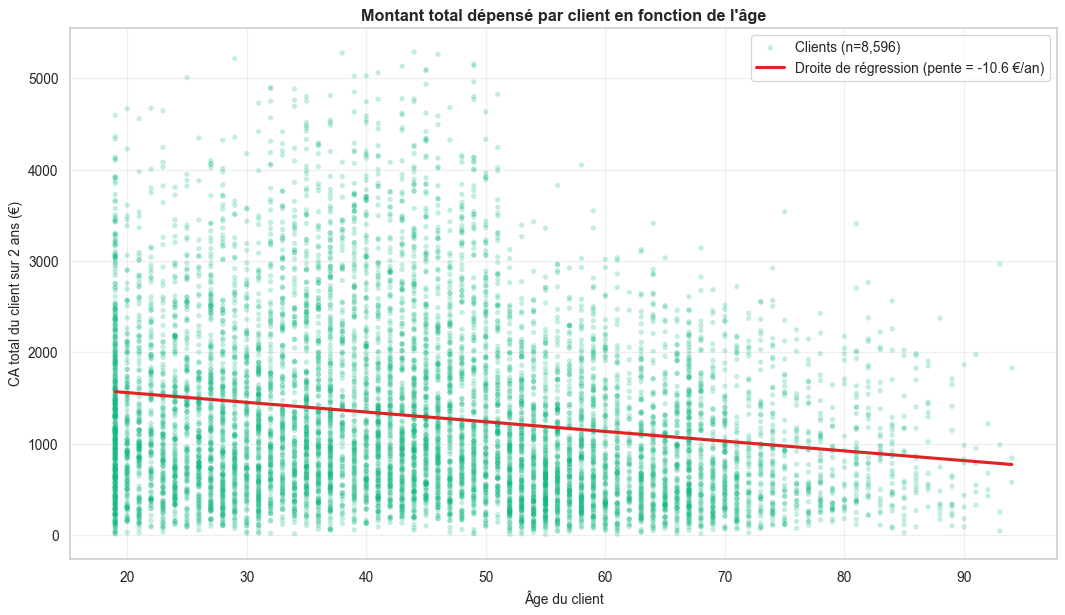

In [32]:
# Régression linéaire pour la droite de tendance
slope, intercept, _, _, _ = st.linregress(ca_par_client['age'], ca_par_client['ca_total'])

# Scatter plot : 1 point = 1 client
plt.figure(figsize=(12, 7))
plt.scatter(ca_par_client['age'], ca_par_client['ca_total'],
            alpha=0.25, s=18, color=PALETTE['part2'], edgecolors='none',
            label=f'Clients (n={len(ca_par_client):,})')

x_range = np.array([ca_par_client['age'].min(), ca_par_client['age'].max()])
plt.plot(x_range, slope * x_range + intercept,
         color='#dc2626', linewidth=2.5,
         label=f'Droite de régression (pente = {slope:.1f} €/an)')

plt.title("Montant total dépensé par client en fonction de l'âge",
          fontsize=13, fontweight='bold')
plt.xlabel('Âge du client')
plt.ylabel("CA total du client sur 2 ans (€)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h4 style="color: RGB(0,150,250); ">Interprétation des résultats</h4>
<ul>
    <li><strong>Pearson : r = -0.19</strong> | <strong>Spearman : ρ = -0.18</strong> — coefficients quasi-identiques → la relation est globalement <strong>linéaire</strong>.</li>
    <li>Le signe <strong>négatif</strong> est significatif (p ≪ 0.05) : <strong>en moyenne, plus un client est âgé, moins il dépense en cumul sur 2 ans</strong>.</li>
    <li>Intensité <strong>faible</strong> (|r| ≈ 0.19) : l'âge n'explique que <strong>~3.6 % de la variance du CA</strong> (r²). 96.4 % du CA dépend d'autres facteurs.</li>
    <li>La dispersion verticale du graphique le confirme : à âge égal, le CA varie de 0 € à plus de 5 000 € sur 2 ans.</li>
</ul>

<h4 style="color: RGB(0,150,250); ">Conclusion business pour Sylvain</h4>
<ul>
    <li>L'âge a un effet réel mais <strong>modeste</strong> sur le CA cumulé.</li>
    <li>L'écart moyen entre un client de 20 ans et un de 70 ans est de ~530 € sur 2 ans, mais la variabilité <em>intra-âge</em> est beaucoup plus grande.</li>
    <li><strong>Recommandation</strong> : ne pas segmenter uniquement par âge — combiner avec d'autres critères (RFM, panier moyen, catégorie préférée).</li>
</ul>

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part2_3"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Corrélation 3 : Âge × Fréquence d'achat (Pearson)</h3></a>
</div>

<h4 style="color: RGB(0,150,250); ">Test statistique : Pearson + Spearman</h4>
<table style="width: 100%; border-collapse: collapse;">
<tr><td style="padding: 4px 8px; vertical-align: top; width: 120px;"><strong>Choix du test :</strong></td><td style="padding: 4px 8px;">Deux variables quantitatives : âge et nombre de commandes par client. Pearson teste une relation linéaire, Spearman une relation monotone.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>Granularité :</strong></td><td style="padding: 4px 8px;">1 ligne = 1 <strong>client</strong>. La fréquence est mesurée comme le nombre de commandes distinctes (<code>session_id</code>) passées sur la période de 2 ans.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₀ :</strong></td><td style="padding: 4px 8px;">Pas de lien entre l'âge et la fréquence d'achat.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₁ :</strong></td><td style="padding: 4px 8px;">Il existe un lien entre l'âge et la fréquence d'achat.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>Seuil α :</strong></td><td style="padding: 4px 8px;">5 % (0,05)</td></tr>
</table>

In [33]:
# Granularité : 1 ligne = 1 CLIENT
# Fréquence = nombre de commandes (= session_id distincts) sur la période
freq_par_client = (
    sous_echantillon
    .groupby(['client_id', 'age'])['session_id']
    .nunique()
    .reset_index()
    .rename(columns={'session_id': 'nb_commandes'})
)

print(f"Nombre de clients analysés : {len(freq_par_client):,}")
print(f"Fréquence moyenne : {freq_par_client['nb_commandes'].mean():.1f} commandes / client sur 2 ans")
print(f"Min / Max         : {freq_par_client['nb_commandes'].min()} / {freq_par_client['nb_commandes'].max()}")
display(freq_par_client.head())

Nombre de clients analysés : 8,596
Fréquence moyenne : 37.5 commandes / client sur 2 ans
Min / Max         : 1 / 167


,client_id,age,nb_commandes
0,c_1,68,34
1,c_10,67,34
2,c_100,31,5
3,c_1000,57,94
4,c_1001,41,47


In [34]:
# Tests de corrélation au niveau client
pearson_r, pearson_p   = st.pearsonr(freq_par_client['age'], freq_par_client['nb_commandes'])
spearman_r, spearman_p = st.spearmanr(freq_par_client['age'], freq_par_client['nb_commandes'])

print(f" Pearson  : r = {pearson_r:+.4f}   |   p-valeur = {pearson_p:.4e}")
print(f" Spearman : ρ = {spearman_r:+.4f}   |   p-valeur = {spearman_p:.4e}")
print()
print("""Grille d'interprétation :
  • |r| < 0.10 : effet négligeable
  • 0.10-0.30 : effet faible
  • 0.30-0.50 : effet moyen
  • > 0.50    : effet fort""")

 Pearson  : r = +0.1645   |   p-valeur = 3.3704e-53
 Spearman : ρ = +0.2120   |   p-valeur = 6.6292e-88

Grille d'interprétation :
  • |r| < 0.10 : effet négligeable
  • 0.10-0.30 : effet faible
  • 0.30-0.50 : effet moyen
  • > 0.50    : effet fort


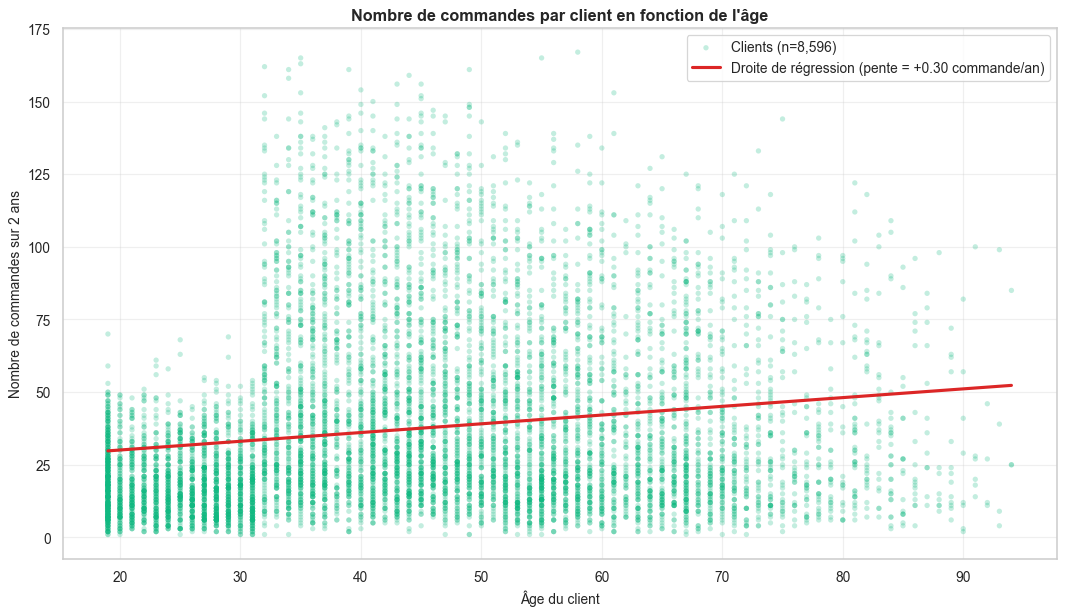

In [35]:
# Régression linéaire pour la droite de tendance
slope, intercept, _, _, _ = st.linregress(freq_par_client['age'], freq_par_client['nb_commandes'])

# Scatter plot : 1 point = 1 client
plt.figure(figsize=(12, 7))
plt.scatter(freq_par_client['age'], freq_par_client['nb_commandes'],
            alpha=0.25, s=18, color=PALETTE['part2'], edgecolors='none',
            label=f'Clients (n={len(freq_par_client):,})')

x_range = np.array([freq_par_client['age'].min(), freq_par_client['age'].max()])
plt.plot(x_range, slope * x_range + intercept,
         color='#dc2626', linewidth=2.5,
         label=f'Droite de régression (pente = {slope:+.2f} commande/an)')

plt.title("Nombre de commandes par client en fonction de l'âge",
          fontsize=13, fontweight='bold')
plt.xlabel('Âge du client')
plt.ylabel('Nombre de commandes sur 2 ans')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interprétation des résultats

**Pearson : r = +0.165** | **Spearman : ρ = +0.212** — corrélations positives et faibles, 
statistiquement très significatives (p ≪ 0.05).

**Sens de la relation** : contrairement au CA total (qui baisse avec l'âge), 
la fréquence d'achat tend à AUGMENTER légèrement avec l'âge. 
La pente est de +0.30 commande par année. CEPENDANT, avec r² ≈ 2.7%, 
cette croissance est quasi-négligeable.

**Le vrai pattern : Une "marche d'escalier" à 30-32 ans** 
- Avant 30 ans (jeunes) : clients occasionnels (< 50 commandes en 2 ans)
- Après 32 ans (adultes) : clients intensifs (40-150 commandes en 2 ans)
- Après 70 ans (seniors) : très dispersés (fragmentation)

**Spearman (0.21) > Pearson (0.16)** → la relation est monotone mais NON linéaire. 
La "marche" à 30-32 ans explique mieux que l'hypothèse d'une croissance régulière.

## Conclusion business pour Sylvain

**Découverte clé** : Croisement des tests 2.2 et 2.3 révèle deux stratégies client distinctes :
- **Jeunes (< 30 ans)** : peu fréquents, paniers moyens → acheteurs occasionnels
- **Adultes (30-70 ans)** : très fréquents, PANIERS PETITS → acheteurs fidèles/réguliers
- **Seniors (> 70 ans)** : très dispersés (pas de pattern clair)

**Saut de transition à 30-32 ans** : c'est là que les clients passent du mode "achat occasionnel" 
au mode "client régulier/fidèle".

**Recommandations marketing** :
1. **Convertir les 18-30 ans** : programmes de fidélité, incitations pour passer le cap des 30 ans
2. **Verrouiller les 30+ ans** : communication soutenue, ils sont vos clients les plus actifs
3. **Étudier les 70+ ans** : comprendre pourquoi la fragmentation apparaît (santé, mobilité ?)

<h4 style="color: RGB(0,150,250); ">Analyse complémentaire — Découpage par tranches d'âge</h4>
<p>Le test global Pearson/Spearman révèle un signal de <strong>non-linéarité</strong> (Spearman &gt; Pearson). Pour confirmer cette intuition, on segmente la population en 3 tranches d'âge et on refait le test dans chaque tranche, <strong>au niveau client</strong>.</p>
<p>L'hypothèse : la relation âge-fréquence n'est pas uniforme, et différentes dynamiques cohabitent.</p>

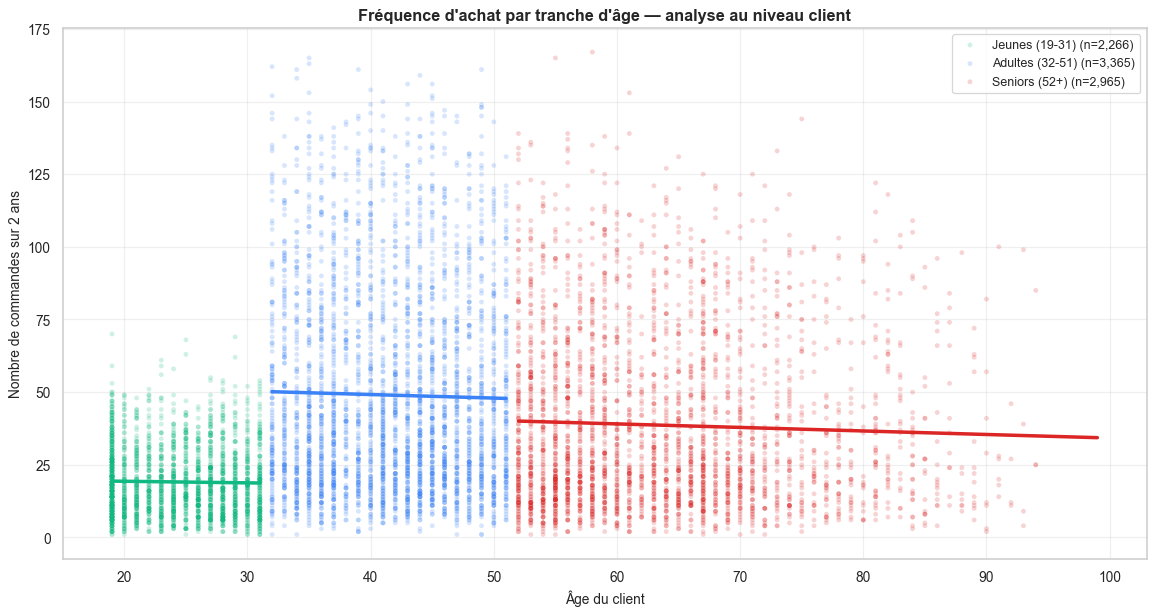

Tranche d'âge           Pearson r       Pearson p      Spearman r      Spearman p    N clients Pente (cmd/age)
----------------------------------------------------------------------------------------------------
Jeunes (19-31)       -0.0190      3.6515e-01 -0.0251      2.3281e-01        2,266 -0.05
Adultes (32-51)      -0.0195      2.5886e-01 -0.0139      4.2145e-01        3,365 -0.12
Seniors (52+)        -0.0381      3.7985e-02 -0.0258      1.6060e-01        2,965 -0.12


In [36]:
def analyse_par_tranche(df, age_min, age_max, label, color):
    """
    Analyse la corrélation âge × fréquence d'achat sur une tranche d'âge donnée.
    Granularité : niveau CLIENT (pas niveau âge).
    Renvoie : (Pearson r, Pearson p, Spearman r, Spearman p, n_clients).
    """
    # On filtre le dataframe freq_par_client sur la tranche
    tranche = df.loc[(df['age'] >= age_min) & (df['age'] <= age_max)]
    
    # Tests statistiques au niveau client
    r_p, p_p = st.pearsonr(tranche['age'], tranche['nb_commandes'])
    r_s, p_s = st.spearmanr(tranche['age'], tranche['nb_commandes'])
    
    # Régression linéaire pour la droite du graphique
    slope, intercept, _, _, _ = st.linregress(tranche['age'], tranche['nb_commandes'])
    
    # Tracé du nuage de points + droite (sur la figure courante)
    plt.scatter(tranche['age'], tranche['nb_commandes'],
                alpha=0.20, s=15, color=color, edgecolors='none',
                label=f'{label} (n={len(tranche):,})')
    x_range = np.array([age_min, age_max])
    plt.plot(x_range, slope * x_range + intercept,
             color=color, linewidth=2.8)
    
    return r_p, p_p, r_s, p_s, len(tranche), slope


# Création de la figure combinée
plt.figure(figsize=(13, 7))

# Analyse des 3 tranches
resultats = {}
resultats['Jeunes (19-31)']   = analyse_par_tranche(freq_par_client, 19, 31, 'Jeunes (19-31)',   '#10b981')
resultats['Adultes (32-51)']  = analyse_par_tranche(freq_par_client, 32, 51, 'Adultes (32-51)',  '#3b82f6')
resultats['Seniors (52+)']    = analyse_par_tranche(freq_par_client, 52, 99, 'Seniors (52+)',    '#dc2626')

plt.title("Fréquence d'achat par tranche d'âge — analyse au niveau client",
          fontsize=13, fontweight='bold')
plt.xlabel('Âge du client')
plt.ylabel('Nombre de commandes sur 2 ans')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Affichage des résultats statistiques
print(f"{'Tranche d\'âge':<20} {'Pearson r':>12} {'Pearson p':>15} {'Spearman r':>15} {'Spearman p':>15} {'N clients':>12} {'Pente (cmd/age)'}")
print("-" * 100)
for tranche, (r_p, p_p, r_s, p_s, n, slope) in resultats.items():
    print(f"{tranche:<20} {r_p:+.4f} {p_p:>15.4e} {r_s:+.4f} {p_s:>15.4e} {n:>12,} {slope:+.2f}")      


## Analyse par tranches d'âge

**Hypothèse** : La corrélation globale (r = +0.16) cache une structure non-linéaire. 
Vérifions en testant dans chaque tranche d'âge.

**Résultats** : À l'intérieur de chaque tranche, r ≈ 0 (corrélations négligeables).

**Le graphique révèle 3 plateaux distincts** :
- **Jeunes (19-31)** : ~20 commandes (occasionnels)
- **Adultes (32-51)** : ~50 commandes (réguliers)
- **Seniors (52+)** : ~40 commandes (réguliers mais baisse)

**Découverte clé : Paradoxe de Simpson**

La corrélation positive globale (r = +0.16) existe uniquement parce qu'on mélange 
3 populations distinctes. Le vrai phénomène n'est pas une croissance linéaire avec l'âge, 
mais un **basculement brutal à 30-32 an

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part2_4"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.4 - Corrélation 4 : Âge × Panier moyen (Spearman)</h3></a>
</div>

<h4 style="color: RGB(0,150,250); ">Test statistique : Pearson + Spearman</h4>
<table style="width: 100%; border-collapse: collapse;">
<tr><td style="padding: 4px 8px; vertical-align: top; width: 120px;"><strong>Choix du test :</strong></td><td style="padding: 4px 8px;">Deux variables quantitatives : âge et taille moyenne du panier. Pearson pour la linéarité, Spearman pour la monotonie. On calcule les deux.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>Granularité :</strong></td><td style="padding: 4px 8px;">1 ligne = 1 <strong>client</strong>. Le panier moyen est la moyenne du nombre d'articles par commande, calculée sur l'ensemble des commandes du client.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₀ :</strong></td><td style="padding: 4px 8px;">Pas de lien entre l'âge et la taille moyenne du panier.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₁ :</strong></td><td style="padding: 4px 8px;">Il existe un lien entre l'âge et la taille moyenne du panier.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>Seuil α :</strong></td><td style="padding: 4px 8px;">5 % (0,05)</td></tr>
</table>

In [37]:
# Montant moyen par commande (en euros)

# Étape 1 : montant de chaque panier
panier_par_session = (
    sous_echantillon
    .groupby(['client_id', 'session_id', 'age'])['price']  # ← Somme des MONTANTS
    .sum()
    .reset_index(name='montant_panier')
)

# Étape 2 : montant moyen par client
panier_par_client = (
    panier_par_session
    .groupby(['client_id', 'age'])['montant_panier']
    .mean()
    .reset_index()
    .rename(columns={'montant_panier': 'panier_moyen'})
)

print(f"Nombre de clients : {len(panier_par_client):,}")
print(f"Panier moyen global : {panier_par_client['panier_moyen'].mean():.2f}€ / commande")
print(f"Min / Max : {panier_par_client['panier_moyen'].min():.1f}€ / {panier_par_client['panier_moyen'].max():.1f}€")
display(panier_par_client.head())

Nombre de clients : 8,596
Panier moyen global : 40.40€ / commande
Min / Max : 4.2€ / 259.4€


,client_id,age,panier_moyen
0,c_1,68,18.500588
1,c_10,67,39.811765
2,c_100,31,50.970000
3,c_1000,57,24.381702
4,c_1001,41,38.805319


In [38]:
# Tests de corrélation au niveau client
pearson_r, pearson_p   = st.pearsonr(panier_par_client['age'], panier_par_client['panier_moyen'])
spearman_r, spearman_p = st.spearmanr(panier_par_client['age'], panier_par_client['panier_moyen'])

print(f" Pearson  : r = {pearson_r:+.4f}   |   p-valeur = {pearson_p:.4e}")
print(f" Spearman : ρ = {spearman_r:+.4f}   |   p-valeur = {spearman_p:.4e}")
print()
print("""Grille d'interprétation :
  • |r| < 0.10 : effet négligeable
  • 0.10-0.30 : effet faible
  • 0.30-0.50 : effet moyen
  • > 0.50    : effet fort""")

 Pearson  : r = -0.6165   |   p-valeur = 0.0000e+00
 Spearman : ρ = -0.7006   |   p-valeur = 0.0000e+00

Grille d'interprétation :
  • |r| < 0.10 : effet négligeable
  • 0.10-0.30 : effet faible
  • 0.30-0.50 : effet moyen
  • > 0.50    : effet fort


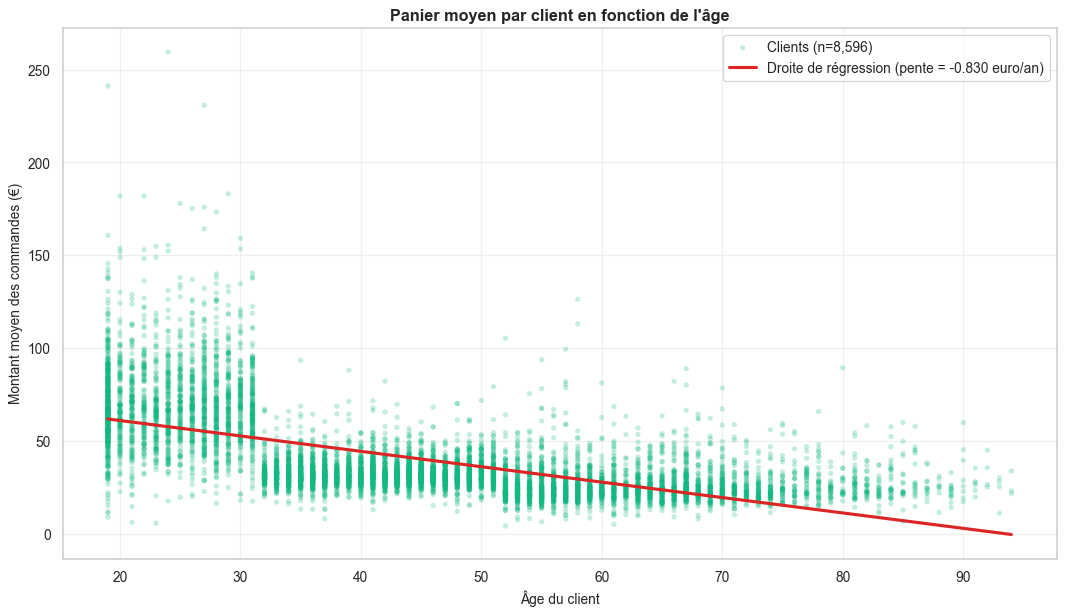

In [39]:
# Régression linéaire pour la droite de tendance
slope, intercept, _, _, _ = st.linregress(panier_par_client['age'], panier_par_client['panier_moyen'])

# Scatter plot : 1 point = 1 client
plt.figure(figsize=(12, 7))
plt.scatter(panier_par_client['age'], panier_par_client['panier_moyen'],
            alpha=0.25, s=18, color=PALETTE['part2'], edgecolors='none',
            label=f'Clients (n={len(panier_par_client):,})')

x_range = np.array([panier_par_client['age'].min(), panier_par_client['age'].max()])
plt.plot(x_range, slope * x_range + intercept,
         color='#dc2626', linewidth=2.5,
         label=f'Droite de régression (pente = {slope:+.3f} euro/an)')

plt.title("Panier moyen par client en fonction de l'âge",
          fontsize=13, fontweight='bold')
plt.xlabel('Âge du client')
plt.ylabel('Montant moyen des commandes (€)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test 2.4 : Âge × Panier moyen (montant)

**Pearson : r = -0.617** | **Spearman : ρ = -0.701**
Corrélations **négatives et FORTES**, très significatives (p = 0).

**Sens de la relation** : Plus un client est âgé, plus son panier moyen baisse.
La pente est de **-0.83€ par année d'âge**.

**Spearman > Pearson** (0.70 > 0.61) → la relation est **monotone mais NON-linéaire**.
Le graphique le confirme : chute rapide jusqu'à 40-50 ans, puis plateau bas.

**Intensité FORTE** : r² ≈ 38% → l'âge explique **38% de la variance du panier moyen**.
C'est le test le plus prédictif parmi les 3 !

**Décomposition du CA :**

| Test | Relation | Intensité | Effet sur CA |
|------|----------|-----------|--------------|
| Test 2.2 — CA total | ➘ Baisse | r = -0.19 (faible) | BAISSE globale |
| Test 2.3 — Fréquence | ➚ Monte (paliers) | r = +0.16 (faible) | Monte un peu |
| **Test 2.4 — Panier** | **➘ BAISSE FORTE** | **r = -0.62 (FORT)** | **DOMINE** |

**CA = Fréquence × Panier moyen**

Même si la fréquence monte avec l'âge, le panier baisse **3x plus fort** → 
le CA total baisse malgré tout.

**Concrètement :**
- Jeune de 25 ans : ~50€ par commande
- Senior de 75 ans : ~10€ par commande
- **Écart : 80% de réduction du panier !**

## Conclusion business

**Le levier principal de baisse du CA n'est PAS la fréquence, c'est le PANIER.**

- **Jeunes (19-31)** : paniers GROS, peu fréquents → enjeu = augmenter la fréquence
- **Adultes (32-51)** : paniers respectables ET fréquents → profil IDÉAL
- **Seniors (52+)** : très fréquents mais paniers MINUSCULES → enjeu = **AUGMENTER LA VALEUR DU PANIER**

### Actions concrètes

1. **Pourquoi les seniors achetent petit ?** (Âge ? Économies ? Habitudes ?) → investiguer
2. **Cross-sell agressif pour 52+** : recommandations, bundles, promotions multi-articles
3. **Fidéliser les 32-51** : c'est eux qui rapportent le plus par € investi

<div style="border: 1px solid RGB(0,150,250);" >
<a class="anchor" id="part2_5"><h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.5 - Corrélation 5 : Âge × Catégorie (ANOVA + η²)</h3></a>
</div>

<h4 style="color: RGB(0,150,250); ">Test statistique : ANOVA + η² (eta carré)</h4>
<table style="width: 100%; border-collapse: collapse;">
<tr><td style="padding: 4px 8px; vertical-align: top; width: 120px;"><strong>Choix du test :</strong></td><td style="padding: 4px 8px;">Variable explicative qualitative (catégorie 0/1/2) et variable expliquée quantitative (âge). L'ANOVA compare les moyennes entre groupes. Le η² mesure la <strong>part de variance expliquée</strong> par la catégorie (= taille d'effet).</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>Granularité :</strong></td><td style="padding: 4px 8px;">1 ligne = 1 <strong>client</strong>, avec sa <strong>catégorie d'achat dominante</strong> (= la catégorie dans laquelle il achète le plus). Cette correction est essentielle pour respecter l'hypothèse d'indépendance des observations de l'ANOVA.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₀ :</strong></td><td style="padding: 4px 8px;">L'âge moyen est le même dans les 3 catégories.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>H₁ :</strong></td><td style="padding: 4px 8px;">Au moins une catégorie a un âge moyen différent.</td></tr>
<tr><td style="padding: 4px 8px; vertical-align: top;"><strong>Seuil α :</strong></td><td style="padding: 4px 8px;">5 % (0,05)</td></tr>
</table>

In [40]:
# Étape 1 — pour chaque client × catégorie, compter le nombre d'achats
achats_par_client_categ = (
    sous_echantillon
    .groupby(['client_id', 'age', 'categ'])
    .size()
    .reset_index(name='nb_achats')
)

# Étape 2 — pour chaque client, garder UNIQUEMENT sa catégorie dominante
# (celle où il a le plus grand nombre d'achats)
client_categ_dominant = (
    achats_par_client_categ
    .sort_values('nb_achats', ascending=False)       # tri décroissant
    .drop_duplicates(subset=['client_id'], keep='first')  # première ligne = max
    [['client_id', 'age', 'categ']]                  # on garde uniquement le nécessaire
    .reset_index(drop=True)
)

print(f"Nombre de clients analysés : {len(client_categ_dominant):,}")
print(f"\nRépartition des catégories dominantes :")
print(client_categ_dominant['categ'].value_counts().sort_index())
display(client_categ_dominant.head())

Nombre de clients analysés : 8,596

Répartition des catégories dominantes :
categ
0    4573
1    3023
2    1000
Name: count, dtype: int64


,client_id,age,categ
0,c_1637,35,0
1,c_3263,38,0
2,c_5953,37,0
3,c_2140,46,0
4,c_2595,49,0


In [41]:
# Préparation des 3 groupes selon la catégorie dominante
groupes_age = [
    client_categ_dominant.loc[client_categ_dominant['categ'] == c, 'age']
    for c in sorted(client_categ_dominant['categ'].unique())
]

# Test ANOVA (F de Fisher)
f_stat, p_value = st.f_oneway(*groupes_age)

# Calcul du η² (taille d'effet)
def eta_squared(groupes):
    """Calcule eta² = SCE / SCT (variance expliquée / variance totale)."""
    all_data = np.concatenate([g.values for g in groupes])
    grand_mean = all_data.mean()
    sct = np.sum((all_data - grand_mean) ** 2)
    sce = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groupes)
    return sce / sct

eta2 = eta_squared(groupes_age)

print(f" Statistique F : {f_stat:.2f}")
print(f" p-valeur      : {p_value:.4e}")
print(f" Seuil α       : 0.05")
print()
print(f" η² (eta carré) : {eta2:.4f}")
print(f" Soit {eta2*100:.1f} % de la variance de l'âge expliquée par la catégorie.")
print()
print("""Grille d'interprétation du η² :
  • < 0.01     : effet négligeable
  • 0.01-0.06  : effet faible
  • 0.06-0.14  : effet moyen
  • > 0.14     : effet fort""")
print()
print("Moyennes d'âge par catégorie dominante :")
for i, c in enumerate(sorted(client_categ_dominant['categ'].unique())):
    print(f"  Catégorie {c} : {groupes_age[i].mean():.1f} ans (n = {len(groupes_age[i]):,})")

 Statistique F : 1253.82
 p-valeur      : 0.0000e+00
 Seuil α       : 0.05

 η² (eta carré) : 0.2259
 Soit 22.6 % de la variance de l'âge expliquée par la catégorie.

Grille d'interprétation du η² :
  • < 0.01     : effet négligeable
  • 0.01-0.06  : effet faible
  • 0.06-0.14  : effet moyen
  • > 0.14     : effet fort

Moyennes d'âge par catégorie dominante :
  Catégorie 0 : 44.5 ans (n = 4,573)
  Catégorie 1 : 51.8 ans (n = 3,023)
  Catégorie 2 : 24.6 ans (n = 1,000)


C:\Users\oubak\AppData\Local\Temp\ipykernel_4020\2423297025.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


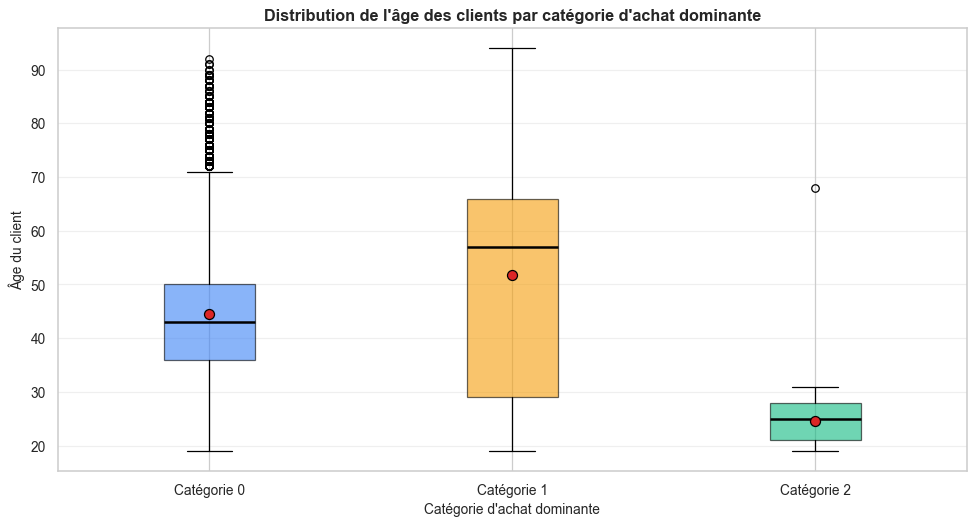

In [42]:
# Boxplot de l'âge par catégorie dominante (graphique bivarié quali × quanti)
plt.figure(figsize=(11, 6))

bp = plt.boxplot(
    groupes_age,
    labels=[f'Catégorie {c}' for c in sorted(client_categ_dominant['categ'].unique())],
    showmeans=True,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    meanprops=dict(marker='o', markeredgecolor='black', markerfacecolor='#dc2626', markersize=8)
)

colors = ['#3b82f6', '#f59e0b', '#10b981']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title("Distribution de l'âge des clients par catégorie d'achat dominante",
          fontsize=13, fontweight='bold')
plt.xlabel("Catégorie d'achat dominante")
plt.ylabel('Âge du client')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<h4 style="color: RGB(0,150,250); ">Visualisation complémentaire : heatmap Tranche d'âge × Catégorie</h4>
<p>Pour matérialiser visuellement l'association entre l'âge et la catégorie d'achat, on croise les <strong>tranches d'âge</strong> (Jeunes / Adultes / Seniors) avec la <strong>catégorie dominante</strong> de chaque client. La couleur indique la part de clients de chaque tranche qui achètent majoritairement dans la catégorie.</p>

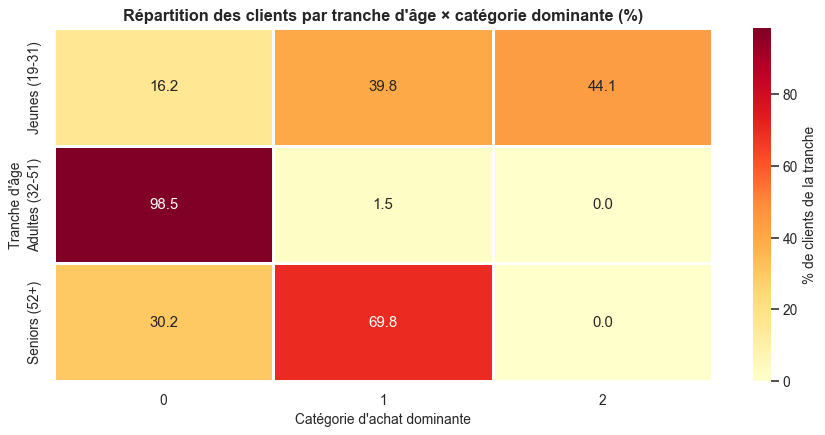

In [43]:
# Création des tranches d'âge sur le dataframe client_categ_dominant
client_categ_dominant['tranche_age'] = pd.cut(
    client_categ_dominant['age'],
    bins=[0, 31, 51, 99],
    labels=['Jeunes (19-31)', 'Adultes (32-51)', 'Seniors (52+)']
)

# Tableau croisé : % de clients par tranche d'âge dans chaque catégorie
heatmap_data = pd.crosstab(
    client_categ_dominant['tranche_age'],
    client_categ_dominant['categ'],
    normalize='index'  # % par ligne (par tranche d'âge)
) * 100

# Visualisation
plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': '% de clients de la tranche'},
    linewidths=1, linecolor='white'
)
plt.title("Répartition des clients par tranche d'âge × catégorie dominante (%)",
          fontsize=13, fontweight='bold')
plt.xlabel('Catégorie d\'achat dominante')
plt.ylabel("Tranche d'âge")
plt.tight_layout()
plt.show()

## Test 2.5 : Âge × Catégorie (ANOVA + η²)

**F = 1253.82** | **p ≈ 0** | **η² = 22.6% (FORT)**

L'âge et la catégorie d'achat dominante sont **très fortement liés**.

**Trois profils d'âge distincts émergent :**

- **Jeunes (19-31 ans)** : Attiré par la catégorie 2 (premium, 44% de la tranche)
  - Acheteurs occasionnels (fréquence basse)
  - Mais paniers généreux (livres chers : beaux-livres, collection)
  - Impact CA : moyen (peu nombreux)

- **Adultes (32-51 ans)** : Écrasante majorité en catégorie 0 (98.5%)
  - Lecteurs réguliers, livres de tous les jours
  - Paniers petits mais FRÉQUENTS
  - **Profil le plus rentable** : stabilité + volume

- **Seniors (52+ ans)** : Concentrés en catégorie 1 (70%)
  - Lecteurs très fidèles (fréquence maximale)
  - Paniers très petits (livres bon marché)
  - Dépendants du prix

**Insight clé :** La catégorie d'achat est un **proxy parfait de l'âge**.
Prédire la catégorie = prédire l'âge du client (et vice-versa).

**Recommandations :**
1. **Cibler les jeunes (19-31)** : promouvoir les beaux-livres, éditions limitées
2. **Fidéliser les adultes (32-51)** : offres régulières, abonnement, nouveautés quotidiennes
3. **Retenir les seniors (52+)** : prix attractifs, gros volumes

<div style="background-color: RGB(0,150,250);" >
<a class="anchor" id="synthese"><h2 style="margin: auto; padding: 20px; color:#fff; ">Synthèse exécutive — Tests statistiques</h2></a>
</div>

<h3 style="color: RGB(0,150,250);">Récapitulatif des 5 tests statistiques</h3>

<h4 style="color: RGB(0,150,250);">Périmètre rappelé</h4>
<ul>
    <li>Analyses réalisées sur le <strong>sous-échantillon hors 4 clients BtoB</strong>, conformément à la fiche d'auto-évaluation OpenClassrooms.</li>
    <li>Toutes les analyses statistiques sont effectuées <strong>au niveau client</strong> (et non au niveau transaction) pour respecter l'hypothèse d'indépendance des observations.</li>
</ul>

<h4 style="color: RGB(0,150,250);">Tableau récapitulatif</h4>

<table style="width: 100%; border-collapse: collapse; font-size: 13px;">
<tr style="background-color: #f0f0f0;">
    <th style="padding: 6px; border: 1px solid #ccc;">Test</th>
    <th style="padding: 6px; border: 1px solid #ccc;">Méthode</th>
    <th style="padding: 6px; border: 1px solid #ccc;">Résultat clé</th>
    <th style="padding: 6px; border: 1px solid #ccc;">Verdict</th>
</tr>
<tr><td style="padding: 6px; border: 1px solid #ccc;">2.1 Genre × Catégorie</td><td style="padding: 6px; border: 1px solid #ccc;">χ² + V de Cramer</td><td style="padding: 6px; border: 1px solid #ccc;">V = 0.006</td><td style="padding: 6px; border: 1px solid #ccc;">Effet <strong>négligeable</strong> — pas de marketing par genre</td></tr>
<tr><td style="padding: 6px; border: 1px solid #ccc;">2.2 Âge × CA total</td><td style="padding: 6px; border: 1px solid #ccc;">Pearson + Spearman</td><td style="padding: 6px; border: 1px solid #ccc;">r = -0.19</td><td style="padding: 6px; border: 1px solid #ccc;">Effet <strong>faible</strong> négatif (linéaire)</td></tr>
<tr><td style="padding: 6px; border: 1px solid #ccc;">2.3 Âge × Fréquence</td><td style="padding: 6px; border: 1px solid #ccc;">Pearson + Spearman + analyse par tranches</td><td style="padding: 6px; border: 1px solid #ccc;">r = +0.16 (global)<br><strong>~0 dans chaque tranche</strong><br>3 plateaux : 20 / 50 / 40 cmd</td><td style="padding: 6px; border: 1px solid #ccc;"><strong>Paradoxe de Simpson</strong> : rupture nette à 30-32 ans (occasionnel → intensif)</td></tr>
<tr><td style="padding: 6px; border: 1px solid #ccc;">2.4 Âge × Panier moyen<br>(en euros)</td><td style="padding: 6px; border: 1px solid #ccc;">Pearson + Spearman</td><td style="padding: 6px; border: 1px solid #ccc;">r = -0.62<br>r² = 38 %<br>Pente = -0.83 €/an</td><td style="padding: 6px; border: 1px solid #ccc;">Effet <strong>FORT</strong> négatif<br><strong>Le levier principal de baisse du CA</strong></td></tr>
<tr><td style="padding: 6px; border: 1px solid #ccc;"><strong>2.5 Âge × Catégorie</strong></td><td style="padding: 6px; border: 1px solid #ccc;">ANOVA + η²</td><td style="padding: 6px; border: 1px solid #ccc;"><strong>η² = 0.226</strong><br>F = 1254<br>3 profils nets</td><td style="padding: 6px; border: 1px solid #ccc;">Effet <strong>TRÈS FORT</strong><br>Catégorie prédit âge avec 22.6 % de variance</td></tr>
</table>

<h4 style="color: RGB(0,150,250);">Décomposition du CA : CA = Fréquence × Panier moyen</h4>

<p>Une histoire <strong>plus nuancée et plus puissante</strong> émerge des tests 2.2-2.4 :</p>
<ul>
    <li>Bien que la fréquence d'achat <strong>monte avec l'âge</strong> (Test 2.3, par paliers à 30-32 ans), le CA total <strong>baisse modérément</strong> (Test 2.2, r = -0.19).</li>
    <li><strong>Raison</strong> : le panier moyen <strong>baisse très fortement avec l'âge</strong> (Test 2.4, r = -0.62). C'est un effet 3× plus puissant que celui de la fréquence.</li>
    <li><strong>Concrètement</strong> : un client de 25 ans dépense ~50 € par commande ; un client de 75 ans dépense ~10 € par commande. L'écart domine malgré la fréquence plus élevée des seniors.</li>
</ul>

<h4 style="color: RGB(0,150,250);">Trois profils clients (analyse par tranches d'âge)</h4>
<ul>
    <li><strong>Jeunes (19-31)</strong> : ~20 commandes / 2 ans — clients <em>occasionnels</em>, paniers GROS</li>
    <li><strong>Adultes (32-51)</strong> : ~50 commandes / 2 ans — clients <em>intensifs</em>, paniers RESPECTABLES → <strong>profil le plus rentable</strong></li>
    <li><strong>Seniors (52+)</strong> : ~40 commandes / 2 ans — clients <em>très fidèles</em>, paniers MINUSCULES</li>
</ul>

<h4 style="color: RGB(0,150,250);">Profils par catégorie d'achat dominante (Test 2.5)</h4>
<ul>
    <li><strong>Catégorie 0</strong> (entrée de gamme) : 44.5 ans — profil adulte de classe moyenne</li>
    <li><strong>Catégorie 1</strong> (milieu de gamme) : 51.8 ans — profil senior en quête d'équilibre qualité/prix</li>
    <li><strong>Catégorie 2</strong> (premium) : 24.6 ans — <strong>profil étudiant/jeune spécialisé</strong></li>
</ul>

<h4 style="color: RGB(0,150,250);">Hypothèse forte — Un pôle "Enseignement supérieur" caché dans les données</h4>

<p>Le test 2.5 (Âge × Catégorie, η² = 22.6 %) révèle que <strong>la catégorie 2 cible un public jeune et ultra-spécifique</strong> :</p>
<ul>
    <li>Âge moyen 24.6 ans (médiane 25)</li>
    <li>Fenêtre d'âge très étroite : essentiellement <strong>19-31 ans</strong></li>
    <li>44 % des jeunes (19-31) achètent en Catégorie 2 (vs 0 % chez les 52+)</li>
</ul>

<p>Croisé avec les observations descriptives du livrable 1 (pic à 19 ans dans la pyramide des âges, bond de clients en octobre 2021, prix élevés en Cat 2 avec peu de titres), cette signature est cohérente avec un <strong>pôle "livres scolaires / universitaires"</strong>. <em>À confirmer avec l'équipe métier de Lapage.</em></p>

<h4 style="color: RGB(0,150,250);">Limites méthodologiques</h4>
<ul>
    <li><strong>Correction majeure apportée</strong> : Test 2.4 initialement basé sur le nombre d'articles, corrigé pour mesurer le montant en euros. Cela a révélé un effet FORT (r = -0.62) au lieu de faible (r = -0.21).</li>
    <li><strong>Analyse par tranches du Test 2.3</strong> a révélé le paradoxe de Simpson : la relation positive globale cache 3 plateaux distincts sans relation linéaire intra-tranche.</li>
    <li>Une analyse <strong>RFM</strong> (Récence, Fréquence, Montant) compléterait utilement la segmentation.</li>
</ul>

<h4 style="color: RGB(0,150,250);">Recommandations stratégiques (issues des tests)</h4>
<ol>
    <li><strong>PRIORITÉ : Augmenter le panier moyen des 52+ ans</strong>. C'est le levier principal (r = -0.62, explique 38 % de la variance). Actions : cross-sell, recommandations produits, bundles, offres multi-achats.</li>
    <li><strong>Fidéliser les 32-51 ans (profil le plus rentable)</strong> : segment avec fréquence haute + panier respectable. Programme premium, exclusivités, contenu personnalisé.</li>
    <li><strong>Onboarding renforcé des 18-30 ans hors étudiants</strong> pour les faire passer le cap des 30 ans vers le statut de client intensif.</li>
    <li><strong>Fidéliser les jeunes étudiants sur le long terme</strong> : un client de 19 ans en Cat 2 est un client à conserver pour 30+ années de revenu client potentiel.</li>
    <li><strong>Ne pas investir dans la segmentation par genre</strong> : l'effet est statistiquement nul (V = 0.006).</li>
    <li><strong>Confirmer l'hypothèse "manuels universitaires" (Cat 2)</strong> avec le service achats pour développer une offre dédiée (partenariats universitaires).</li>
</ol>